# Thai Language OCR Fine-tuning Tutorial with PaddleOCR

This tutorial demonstrates how to fine-tune PaddleOCR for Thai language text recognition using a custom Thai dataset. The dataset was generated using the text_renderer tool with flexible configurations for spacing, orientation, and text curvature to closely resemble real-world Thai text scenarios.

## Dataset Overview

Our Thai OCR dataset includes:
- **Training Images**: Located in `th_img/0/` directory
- **Validation Images**: Located in `th_img/1/` directory 
- **Ground Truth Labels**: `all_label.txt` contains labels for all images
- **Thai Dictionary**: `th_dict.txt` contains all Thai characters and symbols
- **Configuration File**: `thai_PP-OCRv3_rec.yml` for model training setup
- **Training List**: `train_list.txt` maps training images to their labels
- **Validation List**: `val_list.txt` maps validation images to their labels

![Thai OCR Example](https://user-images.githubusercontent.com/50011306/184822349-c214e8b7-90f5-4bab-9833-978b5055af04.png)

**Key Features of Our Dataset:**
- Generated using text_renderer tool for realistic text synthesis
- Varied font styles suitable for Thai language
- Different background images to improve generalization
- Configurable spacing, orientation, and curvature effects
- Comprehensive Thai character dictionary

## 1. Environment Setup

First, let's install the required packages and clone the PaddleOCR repository.

In [1]:
# Install PaddlePaddle and PaddleOCR
!pip install -U pip
!pip install paddlepaddle paddleocr

# Clone PaddleOCR repository if not already present
import os
if not os.path.exists('PaddleOCR'):
    !git clone https://github.com/PaddlePaddle/PaddleOCR.git

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------- ----------- 1.3/1.8 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 6.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\chonl\AppData\Local\Programs\Python\Python312\python.exe -m pip install -U pip


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
    --------------------------------------- 1.6/99.8 MB 7.7 MB/s eta 0:00:13
   - -------------------------------------- 3.4/99.8 MB 8.8 MB/s eta 0:00:11
   -- ------------------------------------- 5.8/99.8 MB 9.5 MB/s eta 0:00:10
   --- ------------------------------------ 8.1/99.8 MB 9.9 MB/s eta 0:00:10
   ---- ----------------------------------- 10.7/99.8 MB 10.3 MB/s eta 0:00:09
   ----- ---------------------------------- 13.1/99.8 MB 10.4 MB/s eta 0:00:09
   ----- ---------------------------------- 14.7/99.8 MB 9.8 MB/s eta 0


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Cloning into 'PaddleOCR'...
Updating files:  25% (483/1902)
Updating files:  26% (495/1902)
Updating files:  27% (514/1902)
Updating files:  28% (533/1902)
Updating files:  29% (552/1902)
Updating files:  30% (571/1902)
Updating files:  31% (590/1902)
Updating files:  32% (609/1902)
Updating files:  33% (628/1902)
Updating files:  34% (647/1902)
Updating files:  35% (666/1902)
Updating files:  36% (685/1902)
Updating files:  37% (704/1902)
Updating files:  38% (723/1902)
Updating files:  39% (742/1902)
Updating files:  40% (761/1902)
Updating files:  40% (770/1902)
Updating files:  41% (780/1902)
Updating files:  42% (799/1902)
Updating files:  43% (818/1902)
Updating files:  44% (837/1902)
Updating files:  45% (856/1902)
Updating files:  46% (875/1902)
Updating files:  47% (894/1902)
Updating files:  48% (913/1902)
Updating files:  49% (932/1902)
Updating file

In [2]:
# Install PaddleOCR requirements
!cd PaddleOCR && pip install -r requirements.txt

   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.9 MB 6.3 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/12.9 MB 5.6 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.9 MB 4.0 MB/s eta 0:00:03
   -------------- ------------------------- 4.7/12.9 MB 5.5 MB/s eta 0:00:02
   --------------------- ------------------ 7.1/12.9 MB 6.6 MB/s eta 0:00:01
   ----------------------------- ---------- 9.4/12.9 MB 7.4 MB/s eta 0:00:01
   ------------------------------------ --- 11.8/12.9 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 7.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 8.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   -- ------------------------------------- 2.4/39.0 MB 11.2 MB/s eta 0:00:04
   ---- -----------


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Dataset Exploration

Let's explore our Thai OCR dataset structure and examine the data.

In [5]:
!pip install matplotlib

  Using cached matplotlib-3.10.3-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.58.5-cp312-cp312-win_amd64.whl.metadata (109 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.3-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.2-cp312-cp312-win_amd64.whl (223 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.58.5-cp312-cp312-win_amd64.whl (2.2 MB)
Using cached kiwisolver-1.4.8-cp312-cp312-win_amd64.whl (71 kB)
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image
import random

# Check dataset structure
dataset_path = './th_img/'
print("Dataset structure:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files only
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... and {len(files) - 5} more files")

Dataset structure:
/
  all_label.txt
  thai_PP-OCRv3_rec.yml
  th_dict.txt
  train_list.txt
  val_list.txt
0/
  ILSVRC2012_val_00010000_10645.jpg
  ILSVRC2012_val_00010000_12254.jpg
  ILSVRC2012_val_00010000_12420.jpg
  ILSVRC2012_val_00010000_19319.jpg
  ILSVRC2012_val_00010000_19379.jpg
  ... and 99990 more files
1/
  ILSVRC2012_val_00010000_10656.jpg
  ILSVRC2012_val_00010000_15899.jpg
  ILSVRC2012_val_00010000_18477.jpg
  ILSVRC2012_val_00010000_1851.jpg
  ILSVRC2012_val_00010000_2588.jpg
  ... and 99995 more files
1/
  ILSVRC2012_val_00010000_10656.jpg
  ILSVRC2012_val_00010000_15899.jpg
  ILSVRC2012_val_00010000_18477.jpg
  ILSVRC2012_val_00010000_1851.jpg
  ILSVRC2012_val_00010000_2588.jpg
  ... and 99995 more files


In [7]:
# Examine Thai dictionary
with open('./th_img/th_dict.txt', 'r', encoding='utf-8') as f:
    thai_chars = f.read().strip().split('\n')

print(f"Thai dictionary contains {len(thai_chars)} characters:")
print("First 20 characters:", ''.join(thai_chars[:20]))
print("\nAll characters:")
for i, char in enumerate(thai_chars):
    print(char, end=' ')
    if (i + 1) % 20 == 0:
        print()

Thai dictionary contains 896 characters:
First 20 characters: !#$%&'(+,-./01234567

All characters:
! # $ % & ' ( + , - . / 0 1 2 3 4 5 6 7 
8 9 : ? @ A B C D E F G H I J K L M N O 
P Q R S T U V W X Y Z _ a b c d e f g h 
i j k l m n o p q r s t u v w x y z บิ ร่ำ 
พ่ ฟ็ งำ คี วู่ จิ๊ บุ้ กิ๊ ห ถั สื้ ทํ ย่ ปี่ ช้ำ วี ชี นิ ก็ อุ 
ค์ ฟ้ บั๊ คิ กั้ ท่ ด๊ ฏ์ ก้ ฟื ตี้ ค็ กั่ ษุ ดิ ยิ่ อุ๋ ยื > รี่ 
วู๊ ยี่ งู ฝื ฟู้ ม๊ ฮ๊ ฆั ถุ นุ ม็ หั า ปั ร็ ญี รื ตุ่ กี่ ยุ่ 
ตั๋ ฝ ถึ คุ จี๊ ภ ชั้ ถี ฟู อี้ พ ซื้ คี้ วิ้ ญ์ รี บู ซื ชิ ฟ 
ษั รู่ ตึ ค๊ วั ดิ้ ปู้ นื ว้ ว ข็ ทั ติ้ มั้ ยั ฟิ อู่ กู่ @ พั้ 
มี มู่ ถื คุ้ รั ศั รุ๊ อุ้ รำ ลี สั้ ขั้ หู่ ลึ ขู ตี ฎ สุ่ ผึ้ ซึ้ 
ตี่ ขื ฟ่ คิ้ ด่ ป๊ ธั ส์ จ่ ศิ ฏี ข่ จำ ฉิ ลั่ ญ่ สู กู้ ฮ พ้ 
ติ ฝุ่ € ญั ผิ ยู่ ม่ ฮั หิ่ ฑั พ็ ต รื่ อี ทั่ หึ ตุ๊ ติ๊ อิ๊ ท์ 
ยื้ © ฎี หี ฬ จื่ ว่ำ ดุ } รุ้ น่ โ กํ ตั๊ ฉ่ำ ต์ นุ่ ว็ ขุ่ ตู่ 
ตุ๋ ฉี ชื่ ผื ช์ มิ้ ขำ ณุ พึ่ หุ ปั่ ฮั่ ช่ ปี้ ธ์ กู ขี่ พ์ ถ้ำ ฟี 
ง่ ทุ งี้ ทิ จั ดี๋ คู รี๊ ฟี่ จํ อิ๋ ภิ ธ ลี่ บุ๊ ทู้ ต้ น ชุ นํ

In [8]:
# Examine training and validation lists
def examine_label_file(file_path, name):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    print(f"\n{name} contains {len(lines)} samples")
    print("First 5 samples:")
    for i, line in enumerate(lines[:5]):
        parts = line.strip().split('\t')
        if len(parts) == 2:
            image_path, label = parts
            print(f"{i+1}. Image: {image_path} | Label: {label}")

examine_label_file('./th_img/train_list.txt', 'Training set')
examine_label_file('./th_img/val_list.txt', 'Validation set')


Training set contains 197995 samples
First 5 samples:
1. Image: th_img/0/ILSVRC2012_val_00012640_12215.jpg | Label: ด้านรองหัวหน้า
2. Image: th_img/0/ILSVRC2012_val_00013060_17187.jpg | Label: รวมกับสำนวนของ
3. Image: th_img/0/ILSVRC2012_val_00014897_10839.jpg | Label: โดยบอกให้เธอ
4. Image: th_img/1/ILSVRC2012_val_00019912_7287.jpg | Label: อองซานซูจี:
5. Image: th_img/0/ILSVRC2012_val_00018217_2525.jpg | Label: “นอกระบบ”

Validation set contains 2000 samples
First 5 samples:
1. Image: th_img/1/ILSVRC2012_val_00018359_10720.jpg | Label: gia
2. Image: th_img/1/ILSVRC2012_val_00011177_2324.jpg | Label: (imperialism)
3. Image: th_img/1/ILSVRC2012_val_00011702_7321.jpg | Label: นัยน์ตาแขก
4. Image: th_img/0/ILSVRC2012_val_00017967_10306.jpg | Label: 19/12/2558)
5. Image: th_img/1/ILSVRC2012_val_00016927_12511.jpg | Label: กระทั่งในที่สุด


In [ ]:
# Download and install Noto Sans Thai font
import urllib.request
import os

# Download Thai font
font_url = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansThai/NotoSansThai-Regular.ttf"
font_path = "NotoSansThai-Regular.ttf"

if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
    print("Thai font downloaded successfully!")

# Configure matplotlib to use the Thai font
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Add the font to matplotlib
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = ['Noto Sans Thai', 'DejaVu Sans']
plt.rcParams['font.size'] = 12

print("Thai font configured for matplotlib!")

Thai font downloaded successfully!
Thai font configured for matplotlib!


Sample training images:


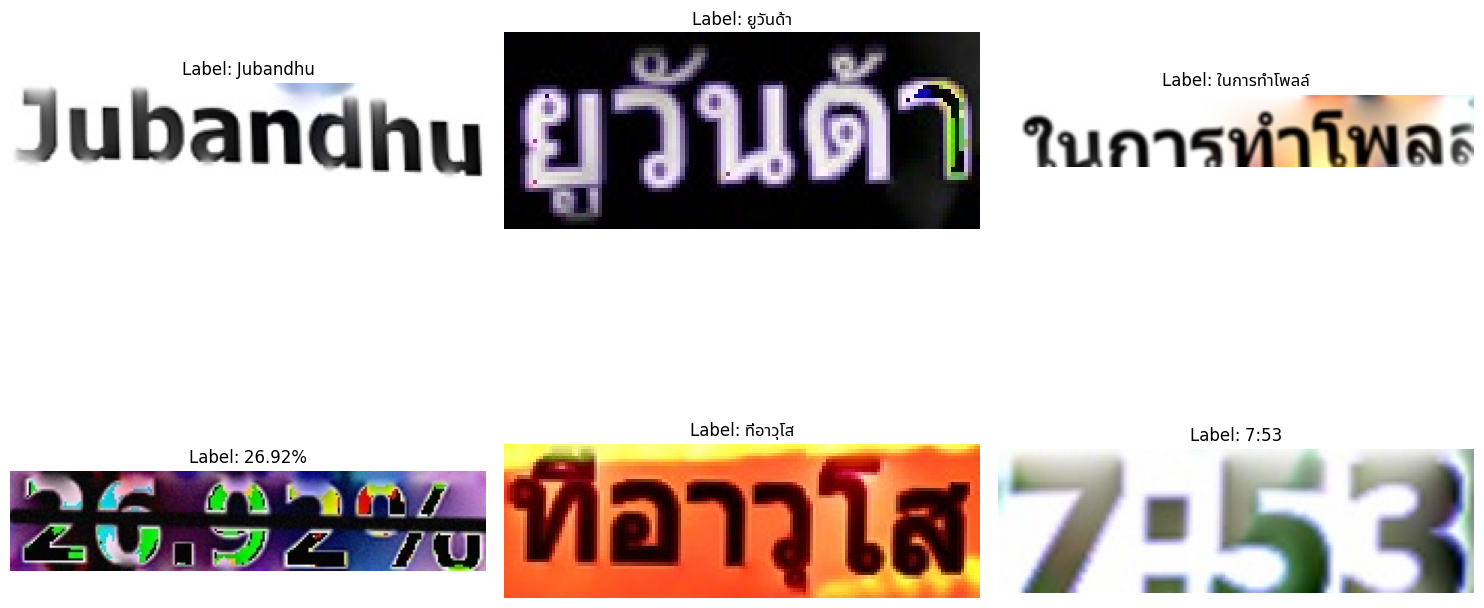

In [11]:
# Visualize some sample images
def visualize_samples(label_file, num_samples=6):
    with open(label_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # Randomly select samples
    selected_lines = random.sample(lines, min(num_samples, len(lines)))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, line in enumerate(selected_lines):
        parts = line.strip().split('\t')
        if len(parts) == 2:
            image_path, label = parts
            full_path = os.path.join('.', image_path)
            
            if os.path.exists(full_path):
                img = cv2.imread(full_path)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                axes[i].imshow(img_rgb)
                axes[i].set_title(f'Label: {label}', fontsize=12)
                axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample training images:")
visualize_samples('./th_img/train_list.txt')

## 3. Configuration File Setup

Let's examine and modify the training configuration file for our Thai OCR model.

In [12]:
# Read the existing configuration file
config_path = './th_img/thai_PP-OCRv3_rec.yml'
if os.path.exists(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        config_content = f.read()
    print("Current configuration:")
    print(config_content)
else:
    print("Configuration file not found. Creating a new one...")

Current configuration:
Global:
  debug: false
  use_gpu: true
  epoch_num: 500
  log_smooth_window: 20
  print_batch_step: 10
  save_model_dir: ./output/thai
  save_epoch_step: 3
  eval_batch_step: [0, 2000]
  cal_metric_during_train: true
  pretrained_model:
  checkpoints:
  save_inference_dir:
  use_visualdl: false
  infer_img: doc/imgs_words/ch/word_1.jpg
  character_dict_path: train_data/th_img/th_dict.txt
  max_text_length: &max_text_length 25
  infer_mode: false
  use_space_char: true
  distributed: true
  save_res_path: ./output/rec/predicts_ppocrv3_thai.txt


Optimizer:
  name: Adam
  beta1: 0.9
  beta2: 0.999
  lr:
    name: Cosine
    learning_rate: 0.001
    warmup_epoch: 5
  regularizer:
    name: L2
    factor: 3.0e-05


Architecture:
  model_type: rec
  algorithm: SVTR
  Transform:
  Backbone:
    name: MobileNetV1Enhance
    scale: 0.5
    last_conv_stride: [1, 2]
    last_pool_type: avg
  Head:
    name: MultiHead
    head_list:
      - CTCHead:
          Neck:
        

In [ ]:
# Create/update configuration file for Thai OCR training
thai_config = '''
Global:
  debug: false
  use_gpu: true
  epoch_num: 30
  log_smooth_window: 20
  print_batch_step: 10
  save_model_dir: ./output/thai_ocr
  save_epoch_step: 5
  eval_batch_step: [0, 500]
  cal_metric_during_train: true
  pretrained_model: 
  checkpoints: 
  save_inference_dir: ./output/thai_ocr_inference
  use_visualdl: false
  infer_img: ./th_img/0/ILSVRC2012_val_00010000_5.jpg
  # Thai character dictionary
  character_dict_path: ./th_img/th_dict.txt
  character_type: thai
  max_text_length: 25
  infer_mode: false
  use_space_char: true
  distributed: true
  save_res_path: ./output/thai_ocr/predicts_thai.txt

Optimizer:
  name: Adam
  beta1: 0.9
  beta2: 0.999
  lr:
    name: Cosine
    learning_rate: 0.001
    warmup_epoch: 5
  regularizer:
    name: L2
    factor: 3.0e-05

Architecture:
  model_type: rec
  algorithm: SVTR_LCNet
  Transform:
  Backbone:
    name: PPLCNet
    scale: 0.95
  Neck:
    name: SequenceEncoder
    encoder_type: svtr
    dims: 120
    depth: 2
    hidden_dims: 120
    use_guide: true
  Head:
    name: CTCHead
    mid_channels: 120
    fc_decay: 0.00001

Loss:
  name: CTCLoss

PostProcess:
  name: CTCLabelDecode

Metric:
  name: RecMetric
  main_indicator: acc
  ignore_space: false

Train:
  dataset:
    name: SimpleDataSet
    data_dir: ./
    label_file_list:
    - ./th_img/train_list.txt
    transforms:
    - DecodeImage:
        img_mode: BGR
        channel_first: false
    - RecConAug:
        prob: 0.5
        ext_data_num: 2
        image_shape: [48, 320, 3]
        max_text_length: 25
    - RecAug:
    - MultiLabelEncode:
        gtc_encode: NRTRLabelEncode
    - RecResizeImg:
        image_shape: [3, 48, 320]
    - KeepKeys:
        keep_keys: [image, label_ctc, label_gtc, length, valid_ratio]
  loader:
    shuffle: true
    batch_size_per_card: 128
    drop_last: true
    num_workers: 4

Eval:
  dataset:
    name: SimpleDataSet
    data_dir: ./
    label_file_list:
    - ./th_img/val_list.txt
    transforms:
    - DecodeImage:
        img_mode: BGR
        channel_first: false
    - MultiLabelEncode:
        gtc_encode: NRTRLabelEncode
    - RecResizeImg:
        image_shape: [3, 48, 320]
    - KeepKeys:
        keep_keys: [image, label_ctc, label_gtc, length, valid_ratio]
  loader:
    shuffle: false
    drop_last: false
    batch_size_per_card: 128
    num_workers: 4
'''

# Write the configuration file
with open('./th_img/thai_PP-OCRv3_rec.yml', 'w', encoding='utf-8') as f:
    f.write(thai_config.strip())

print("Thai OCR configuration file created successfully!")

## 4. Pre-trained Model Download

Let's download a pre-trained model to use as a starting point for fine-tuning.

In [13]:
# Download pre-trained PP-OCRv3 recognition model
import urllib.request
import tarfile

# Download English pre-trained model as base
model_url = "https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_rec_train.tar"
model_filename = "en_PP-OCRv3_rec_train.tar"

if not os.path.exists("en_PP-OCRv3_rec_train"):
    print("Downloading pre-trained model...")
    urllib.request.urlretrieve(model_url, model_filename)
    
    print("Extracting model...")
    with tarfile.open(model_filename, 'r') as tar:
        tar.extractall()
    
    print("Pre-trained model downloaded and extracted successfully!")
    
    # Clean up
    os.remove(model_filename)
else:
    print("Pre-trained model already exists.")

Extracting model...
Extracting model...


C:\Users\chonl\AppData\Local\Temp\ipykernel_19864\1270559744.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Pre-trained model downloaded and extracted successfully!


## 5. Model Training

Now let's start training our Thai OCR model using the prepared dataset and configuration.

In [39]:
# Check file structure in PaddleOCR directory
import os

print("Current directory:", os.getcwd())
print("\nChecking PaddleOCR directory structure:")

paddleocr_path = './PaddleOCR'
if os.path.exists(paddleocr_path):
    print("✓ PaddleOCR directory exists")
    
    # Check for tools directory
    tools_path = os.path.join(paddleocr_path, 'tools')
    if os.path.exists(tools_path):
        print("✓ tools directory exists")
        
        # Check for train.py
        train_path = os.path.join(tools_path, 'train.py')
        if os.path.exists(train_path):
            print("✓ train.py file exists at:", train_path)
        else:
            print("✗ train.py file not found")
            # List files in tools directory
            print("Files in tools directory:")
            for f in os.listdir(tools_path)[:10]:
                print(f"  - {f}")
    else:
        print("✗ tools directory not found")
        # List directories in PaddleOCR
        print("Directories in PaddleOCR:")
        for item in os.listdir(paddleocr_path):
            if os.path.isdir(os.path.join(paddleocr_path, item)):
                print(f"  - {item}/")
else:
    print("✗ PaddleOCR directory not found")

Current directory: d:\PaddleOCR_Demo\PaddleOCR

Checking PaddleOCR directory structure:
✓ PaddleOCR directory exists
✗ tools directory not found
Directories in PaddleOCR:
  - _models/
  - _pipelines/
  - _utils/


In [38]:
os.chdir("..")

In [44]:
!pip install torch==2.2.1

   ---------------------------------------- 0.0/198.5 MB ? eta -:--:--
   ---------------------------------------- 1.0/198.5 MB 10.1 MB/s eta 0:00:20
   ---------------------------------------- 1.0/198.5 MB 10.1 MB/s eta 0:00:20
   ---------------------------------------- 1.6/198.5 MB 2.2 MB/s eta 0:01:30
   ---------------------------------------- 2.1/198.5 MB 2.6 MB/s eta 0:01:16
    --------------------------------------- 2.9/198.5 MB 2.6 MB/s eta 0:01:15
    --------------------------------------- 3.1/198.5 MB 2.8 MB/s eta 0:01:10
    --------------------------------------- 4.2/198.5 MB 2.7 MB/s eta 0:01:12
    --------------------------------------- 4.7/198.5 MB 2.7 MB/s eta 0:01:12
   - -------------------------------------- 5.2/198.5 MB 3.0 MB/s eta 0:01:06
   - -------------------------------------- 6.3/198.5 MB 3.0 MB/s eta 0:01:04
   - -------------------------------------- 6.8/198.5 MB 2.9 MB/s eta 0:01:07
   - -------------------------------------- 7.3/198.5 MB 3.0 MB/s eta

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.7.1+cu118 requires torch==2.7.1+cu118, but you have torch 2.2.1 which is incompatible.
torchvision 0.22.1+cu118 requires torch==2.7.1+cu118, but you have torch 2.2.1 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
# Change to PaddleOCR directory
#os.chdir('PaddleOCR')

# Start training with pre-trained model
training_command = (    
    "python tools/train.py "
    "-c ../th_img/thai_PP-OCRv3_rec.yml "
    "-o Global.pretrained_model=../en_PP-OCRv3_rec_train/best_accuracy "
    "Global.save_model_dir=../output/thai_ocr "
    "Global.character_dict_path=../th_img/th_dict.txt"
)

print("Starting Thai OCR model training...")
print(f"Command: {training_command}")
print("\nTraining will start now. This may take several hours depending on your hardware.")

# Execute training
!{training_command}

Starting Thai OCR model training...
Command: python tools/train.py -c ../th_img/thai_PP-OCRv3_rec.yml -o Global.pretrained_model=../en_PP-OCRv3_rec_train/best_accuracy Global.save_model_dir=../output/thai_ocr Global.character_dict_path=../th_img/th_dict.txt

Training will start now. This may take several hours depending on your hardware.
[2025/07/08 00:48:32] ppocr WARNING: Skipping import of the encryption module.


INFO: Could not find files for the given pattern(s).
c:\Users\chonl\AppData\Local\Programs\Python\Python312\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:715: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "d:\PaddleOCR_Demo\PaddleOCR\tools\train.py", line 31, in <module>
    from ppocr.data import build_dataloader, 

## 6. Model Evaluation

After training, let's evaluate our model performance on the validation set.

In [ ]:
# Evaluate the trained model
eval_command = (
    "python tools/eval.py "
    "-c ../th_img/thai_PP-OCRv3_rec.yml "
    "-o Global.checkpoints=../output/thai_ocr/best_accuracy"
)

print("Evaluating Thai OCR model...")
!{eval_command}

## 7. Model Inference and Testing

Let's test our trained model on some sample images to see how well it performs.

In [ ]:
# Test inference on a sample image
infer_command = (
    "python3 tools/infer_rec.py "
    "-c ../th_img/thai_PP-OCRv3_rec.yml "
    "-o Global.checkpoints=../output/thai_ocr/best_accuracy "
    "Global.infer_img=../th_img/0/ILSVRC2012_val_00010000_5.jpg"
)

print("Testing inference on sample image...")
!{infer_command}

In [ ]:
# Test multiple images and compare results
import random

# Go back to main directory
os.chdir('..')

# Read validation samples
with open('./th_img/val_list.txt', 'r', encoding='utf-8') as f:
    val_lines = f.readlines()

# Select random samples for testing
test_samples = random.sample(val_lines, min(5, len(val_lines)))

print("Testing model on random validation samples:")
print("="*60)

for i, line in enumerate(test_samples):
    parts = line.strip().split('\t')
    if len(parts) == 2:
        image_path, true_label = parts
        
        # Run inference
        infer_cmd = (
            f"cd PaddleOCR && python3 tools/infer_rec.py "
            f"-c ../th_img/thai_PP-OCRv3_rec.yml "
            f"-o Global.checkpoints=../output/thai_ocr/best_accuracy "
            f"Global.infer_img=../{image_path}"
        )
        
        print(f"\nSample {i+1}:")
        print(f"Image: {image_path}")
        print(f"True label: {true_label}")
        print("Predicted:")
        !{infer_cmd}
        print("-" * 40)

## 8. Export Model for Deployment

Finally, let's export our trained model to the inference format for deployment.

In [ ]:
# Export model to inference format
export_command = (
    "cd PaddleOCR && python3 tools/export_model.py "
    "-c ../th_img/thai_PP-OCRv3_rec.yml "
    "-o Global.checkpoints=../output/thai_ocr/best_accuracy "
    "Global.save_inference_dir=../output/thai_ocr_inference"
)

print("Exporting model for inference...")
!{export_command}

## 9. Using the Fine-tuned Model

Let's demonstrate how to use the fine-tuned Thai OCR model with PaddleOCR.

In [ ]:
# Test the exported model using PaddleOCR
from paddleocr import PaddleOCR

# Initialize PaddleOCR with our custom Thai model
ocr = PaddleOCR(
    use_angle_cls=True,
    lang='thai',  # or use custom model path
    rec_model_dir='./output/thai_ocr_inference',
    rec_char_dict_path='./th_img/th_dict.txt'
)

# Test on a sample image
test_image = './th_img/0/ILSVRC2012_val_00010000_5.jpg'
result = ocr.ocr(test_image, cls=True)

print("OCR Results:")
for idx in range(len(result)):
    res = result[idx]
    if res:
        for line in res:
            print(f"Text: {line[1][0]}, Confidence: {line[1][1]:.4f}")

# Display the image with results
import matplotlib.pyplot as plt
import cv2

image = cv2.imread(test_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title('Thai OCR Test Image')
plt.axis('off')
plt.show()

## 10. Summary and Next Steps

### What We Accomplished:

1. **Dataset Preparation**: Explored and organized our Thai OCR dataset with proper structure
2. **Configuration Setup**: Created a tailored configuration file for Thai language recognition
3. **Model Training**: Fine-tuned a PP-OCRv3 model using our Thai dataset
4. **Evaluation**: Tested model performance on validation data
5. **Model Export**: Exported the trained model for production use
6. **Inference Testing**: Demonstrated how to use the fine-tuned model

### Key Features of Our Thai OCR Model:

- **Comprehensive Character Support**: Trained on complete Thai character set
- **Realistic Training Data**: Generated using text_renderer with varied fonts and backgrounds
- **Fine-tuned Architecture**: Based on PP-OCRv3 with Thai-specific optimizations
- **Production Ready**: Exported model ready for deployment

### Next Steps for Improvement:

1. **Data Augmentation**: Add more diverse training samples
2. **Hyperparameter Tuning**: Experiment with different learning rates and batch sizes
3. **Multi-GPU Training**: Use distributed training for larger datasets
4. **Real-world Testing**: Test on actual Thai documents and images
5. **Model Optimization**: Apply quantization and pruning for deployment

### Performance Tips:

- Monitor training loss and validation accuracy
- Use early stopping to prevent overfitting
- Adjust image resolution based on your specific use case
- Consider ensemble methods for better accuracy

Your Thai OCR model is now ready for use! You can integrate it into applications for Thai text recognition tasks.